In [4]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#1. Load and prep the data
url = "https://raw.githubusercontent.com/berkk55/DS4-World-Cup-Project-Phase/main/data/ml_df.csv"
ml_df = pd.read_csv(url)
ml_df = ml_df.sort_values("date").reset_index(drop=True)

#2. Split the data (Train up to 2018)
train_df = ml_df[ml_df["year"] <= 2018]
target = 'home_team_win'
y_train = train_df[target]

In [5]:
# --- ATTEMPT 1: BASELINE MODEL ---
# Simple model using only the teams' total past wins
basic_features = ['home_total_wins_before', 'away_total_wins_before']

# Fill empty fields (NaN) with 0 to be safe
X_train_basic = train_df[basic_features].fillna(0)

# Create and train the simple model
basic_model = LogisticRegression(max_iter=1000)
basic_model.fit(X_train_basic, y_train)

# Briefly check how well this simple model performs on the training data
acc_basic = accuracy_score(y_train, basic_model.predict(X_train_basic))
print("--- Attempt 1: Baseline Model ---")
print(f"Features: {basic_features}")
print(f"Accuracy: {acc_basic * 100:.2f}%\n")

--- Attempt 1: Baseline Model ---
Features: ['home_total_wins_before', 'away_total_wins_before']
Accuracy: 60.03%



In [6]:
# --- ATTEMPT 2: IMPROVED MODEL ---
# Using the calculated "difference" features
advanced_features = ['win_rate_diff', 'goal_diff_diff', 'form_diff', 'elo_diff']
X_train_adv = train_df[advanced_features].fillna(0)

# Making an example of the model and training it
improved_model = LogisticRegression(max_iter=1000)
improved_model.fit(X_train_adv, y_train)

# Determining the accuracy of the model
acc_adv = accuracy_score(y_train, improved_model.predict(X_train_adv))
print("--- Attempt 2: Improved Model ---")
print(f"Features used: {advanced_features}")
print(f"Accuracy: {acc_adv * 100:.2f}%")
print(f"Improvement over baseline: +{(acc_adv - acc_basic) * 100:.2f}%")

--- Attempt 2: Improved Model ---
Features used: ['win_rate_diff', 'goal_diff_diff', 'form_diff', 'elo_diff']
Accuracy: 63.28%
Improvement over baseline: +3.26%


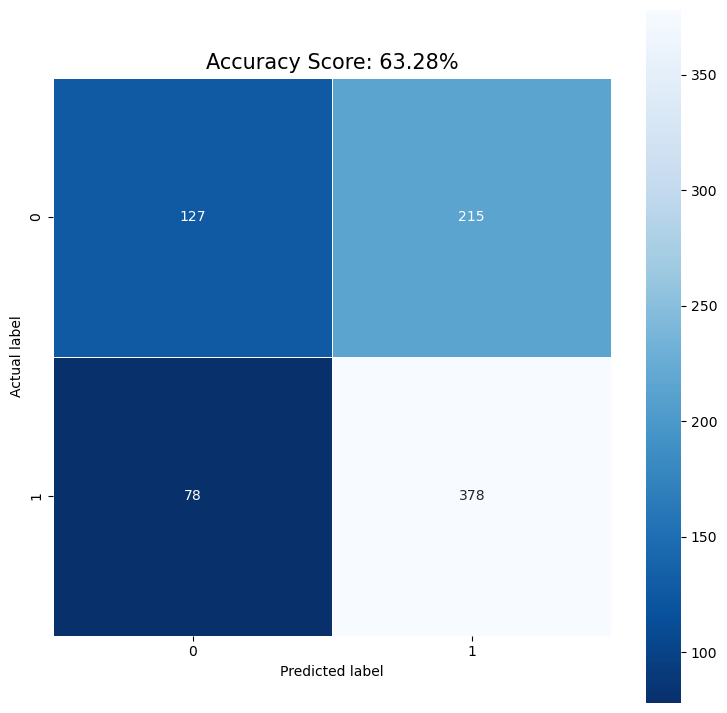

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

# 1. Make predictions for the improved model
predictions = improved_model.predict(X_train_adv)

# 2. Calculate the confusion matrix
cm = metrics.confusion_matrix(y_train, predictions)

# 3. Draw the heatmap (Just like in the Simplilearn video!)
plt.figure(figsize=(9,9))
# fmt=".0f" ensures we see whole numbers (number of matches)
sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square=True, cmap='Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
all_sample_title = f'Accuracy Score: {acc_adv * 100:.2f}%'
plt.title(all_sample_title, size=15)
plt.show()